In [1]:
from google.colab import files
uploaded = files.upload()

Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv


In [14]:
# Task 1: Import Libraries & Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load Dataset
df = pd.read_csv("social_media_engagement_5000.csv")

# Display First Records
print(df.head())

# Dataset Information
print(df.info())
print(df.shape)
print(df.columns)

   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count   posted_at  \
0     354.0  1157.0            5726             44650  17-12-2022   
1    2606.0  1807.0            5947             80216  02-06-2023   
2     344.0   955.0            6946             44858  07-05-2023   
3    1083.0  1049.0             229             70455  12-02-2023   
4    2735.0  1300.0            4798              6019  23-05-2023   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      m

In [15]:
# Task 2: Data Cleaning
# Check Missing Values
print(df.isnull().sum())

# Fill Numeric Missing Values with Median
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill Categorical Missing Values with Mode
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove Duplicates
df.drop_duplicates(inplace=True)

# Convert Date Column
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

# Standardize Text Columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# Remove Negative Values
for col in ['likes','comments','shares','impressions']:
    if col in df.columns:
        df[col] = df[col].abs()


user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


/tmp/ipykernel_3412/1712847970.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_3412/1712847970.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [71]:
# Task 3: Feature Engineering

# Engagement Score
if all(col in df.columns for col in ['likes','comments','shares']):
    df['engagement_score'] = (
        df['likes'] +
        df['comments']*2 +
        df['shares']*3
    )

# Hashtag Count
if 'hashtags' in df.columns:
    df['hashtag_count'] = df['hashtags'].astype(str).apply(
        lambda x: len(x.split())
    )

In [17]:
# Task 4: Data Exploration

print("\nSummary Statistics")
print(df.describe())

# Unique Values
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

# Correlation Matrix
corr_matrix = df.select_dtypes(include=np.number).corr()
print(corr_matrix)

# GroupBy Analysis
if 'post_type' in df.columns and 'likes' in df.columns:
    print(df.groupby('post_type')['likes'].mean())

if 'country' in df.columns and 'impressions' in df.columns:
    print(df.groupby('country')['impressions'].mean())



Summary Statistics
            user_id          age        post_id         likes     comments  \
count   5000.000000  5000.000000    5000.000000   5000.000000  5000.000000   
mean   54561.890800    38.440400  548042.909000  10106.997400  1502.039800   
std    26090.370121    14.687151  260646.957267   5702.293017   856.393312   
min    10055.000000    13.000000  100068.000000     10.000000     0.000000   
25%    32309.500000    26.000000  322543.500000   5235.000000   792.000000   
50%    54374.500000    38.000000  548077.500000  10105.500000  1497.000000   
75%    77180.500000    51.000000  771574.500000  14959.000000  2235.250000   
max    99963.000000    64.000000  999455.000000  19998.000000  2999.000000   

          shares  watch_time_sec  impression_count  follower_count  \
count  5000.0000     5000.000000       5000.000000     5000.000000   
mean   1002.9106     4014.503200      50013.732800   393698.224800   
std     570.8552     2308.096459      28844.939104   230927.884535 

In [18]:
# Task 5: Statistical Analysis

stats_cols = ['likes','comments','shares',
              'watch_time','engagement_rate',
              'followers']

stats_cols = [col for col in stats_cols if col in df.columns]

for col in stats_cols:

    print("\n", "="*50)
    print("Column:", col)

    print("Mean :", df[col].mean())
    print("Median :", df[col].median())
    print("Mode :", df[col].mode()[0])
    print("Std :", df[col].std())
    print("Variance :", df[col].var())

    print("25 Percentile :", df[col].quantile(0.25))
    print("50 Percentile :", df[col].quantile(0.50))
    print("75 Percentile :", df[col].quantile(0.75))


Column: likes
Mean : 10106.9974
Median : 10105.5
Mode : 10105.5
Std : 5702.293017183876
Variance : 32516145.653823998
25 Percentile : 5235.0
50 Percentile : 10105.5
75 Percentile : 14959.0

Column: comments
Mean : 1502.0398
Median : 1497.0
Mode : 1497.0
Std : 856.3933120458967
Variance : 733409.5049169405
25 Percentile : 792.0
50 Percentile : 1497.0
75 Percentile : 2235.25

Column: shares
Mean : 1002.9106
Median : 1012.0
Mode : 1012.0
Std : 570.8551999758862
Variance : 325875.65933950903
25 Percentile : 511.0
50 Percentile : 1012.0
75 Percentile : 1483.0

Column: engagement_rate
Mean : 0.9643560291583999
Median : 0.2538959065
Mode : 0.006362909
Std : 5.318029222661535
Variance : 28.281434813082043
25 Percentile : 0.14578108750000002
50 Percentile : 0.2538959065
75 Percentile : 0.504793702


In [62]:
# Plot 1 Scatter
if all(col in df.columns for col in ['likes','impressions']):
    plt.figure(figsize=(8,5))
    plt.scatter(df['likes'], df['impressions'])
    plt.title('Likes vs Impressions')
    plt.xlabel('Likes')
    plt.ylabel('Impressions')
    plt.show()

In [65]:
# 2 Line Chart
if 'date' in df.columns and 'engagement_score' in df.columns:
    daily = df.groupby('date')['engagement_score'].mean()
    plt.figure(figsize=(10,5))
    plt.plot(daily.index, daily.values)
    plt.title('Daily Engagement Trend')
    plt.xlabel('Date')
    plt.ylabel('Engagement')
    plt.show()


In [64]:
# 3 Bar Chart
if 'category' in df.columns:
    plt.figure(figsize=(8,5))
    df['category'].value_counts().plot(kind='bar')
    plt.title('Posts by Category')
    plt.show()

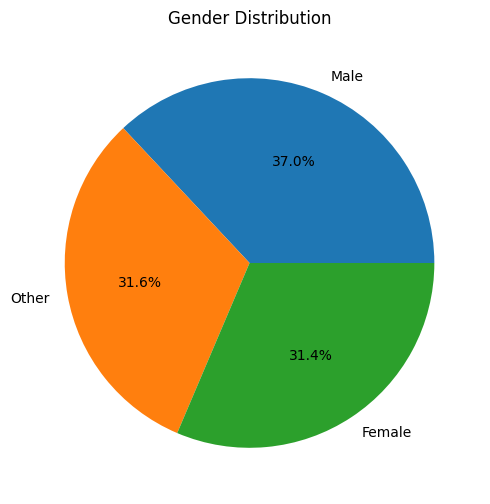

In [66]:
# 4 Pie Chart
if 'gender' in df.columns:
    plt.figure(figsize=(6,6))
    df['gender'].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%'
    )
    plt.ylabel('')
    plt.title('Gender Distribution')
    plt.show()

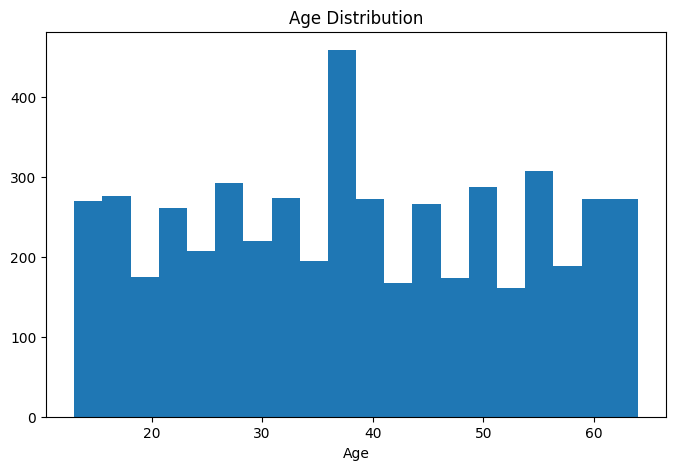

In [29]:
# 5 Histogram
if 'age' in df.columns:
    plt.figure(figsize=(8,5))
    plt.hist(df['age'], bins=20)
    plt.title('Age Distribution')
    plt.xlabel('Age')
    plt.show()

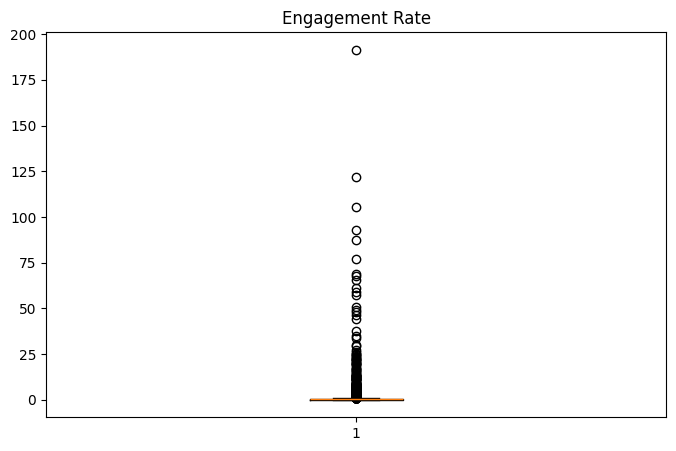

In [30]:

# 6 Box Plot
if 'engagement_rate' in df.columns:
    plt.figure(figsize=(8,5))
    plt.boxplot(df['engagement_rate'])
    plt.title('Engagement Rate')
    plt.show()

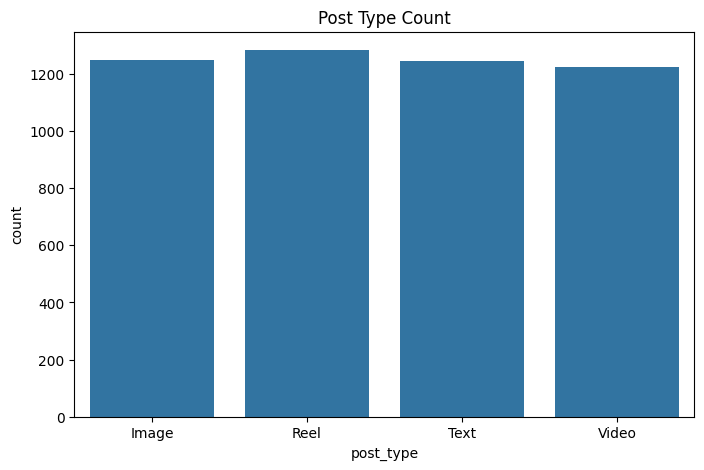

In [31]:
# 7 Count Plot
if 'post_type' in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x='post_type')
    plt.title('Post Type Count')
    plt.show()

In [68]:
# 8 Average Likes by Category
if all(col in df.columns for col in ['category','likes']):
    plt.figure(figsize=(8,5))
    sns.barplot(
        data=df,
        x='category',
        y='likes'
    )
    plt.title('Average Likes by Category')
    plt.xticks(rotation=45)
    plt.show()

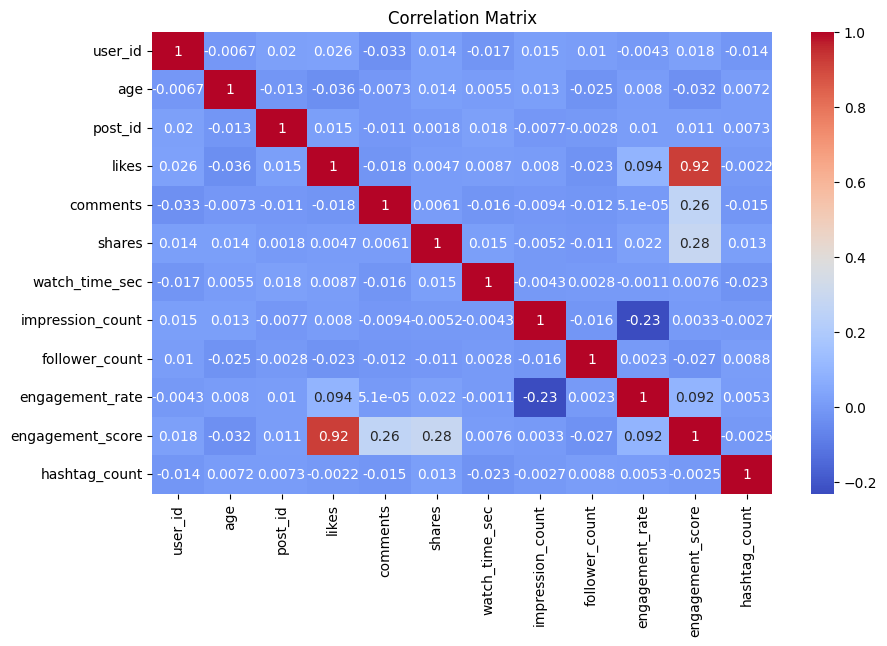

In [33]:
# 9 Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Matrix')
plt.show()

In [70]:
# Plotly Interactive Chart

if all(col in df.columns for col in ['likes','impressions']):
    fig = px.scatter(
        df,
        x='likes',
        y='impressions',
        title='Interactive Likes vs Impressions'
    )
    fig.show()

In [37]:
# Final Insights

print("\nFINAL INSIGHTS")

if 'post_type' in df.columns:
    print("\nHighest Engagement Post Type:")
    print(df.groupby('post_type')['engagement_score'].mean().idxmax())

if 'category' in df.columns:
    print("\nBest Performing Category:")
    print(df.groupby('category')['engagement_score'].mean().idxmax())

if 'country' in df.columns:
    print("\nCountry With Highest Engagement:")
    print(df.groupby('country')['engagement_rate'].mean().idxmax())

if 'sentiment' in df.columns:
    print("\nBest Sentiment:")
    print(df.groupby('sentiment')['engagement_score'].mean().idxmax())

print("\nAnalysis Completed Successfully")


FINAL INSIGHTS

Highest Engagement Post Type:
Image

Country With Highest Engagement:
Brazil

Best Sentiment:
Negative

Analysis Completed Successfully
